- ## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

plt.style.use("default")

plt.rcParams["figure.figsize"] = (12,5)
plt.rcParams["font.size"] = 12

- ## GitHub Raw URLs

In [2]:
RAW_GAP10 = (
    "https://raw.githubusercontent.com/"
    "Adrita-Khan/lightcurve-imputation/main/"
    "data/corrupted_data/gap_10.csv"
)

RAW_GAP30 = (
    "https://raw.githubusercontent.com/"
    "Adrita-Khan/lightcurve-imputation/main/"
    "data/corrupted_data/gap_30.csv"
)

RAW_GAP50 = (
    "https://raw.githubusercontent.com/"
    "Adrita-Khan/lightcurve-imputation/main/"
    "data/corrupted_data/gap_50.csv"
)

- ## Load the Datasets

In [3]:
gap10 = pd.read_csv(RAW_GAP10)
gap30 = pd.read_csv(RAW_GAP30)
gap50 = pd.read_csv(RAW_GAP50)

datasets = {
    "10%": gap10,
    "30%": gap30,
    "50%": gap50
}

print("Datasets loaded successfully.")

Datasets loaded successfully.


- ## Preview the Data

In [4]:
gap10.head()

,time,ideal_flux,observed_flux,corrupted_flux,mask
0,0.0000,1.000000,1.035281,1.035281,1
1,0.0204,1.012783,1.020786,1.020786,1
2,0.0408,1.025356,1.044930,1.044930,1
3,0.0612,1.037512,1.082330,NaN,0
4,0.0816,1.049054,1.086405,1.086405,1


- ## Dataset Information

In [5]:
for name, df in datasets.items():

    print("="*50)

    print(f"Dataset : {name}")

    print(df.info())

    print()

Dataset : 10%
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1324 entries, 0 to 1323
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   time            1324 non-null   float64
 1   ideal_flux      1324 non-null   float64
 2   observed_flux   1324 non-null   float64
 3   corrupted_flux  1192 non-null   float64
 4   mask            1324 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 51.8 KB
None

Dataset : 30%
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1324 entries, 0 to 1323
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   time            1324 non-null   float64
 1   ideal_flux      1324 non-null   float64
 2   observed_flux   1324 non-null   float64
 3   corrupted_flux  927 non-null    float64
 4   mask            1324 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 51.8 KB
None

Dataset : 50%
<c

- ## Summary Table

In [6]:
summary = []

for name, df in datasets.items():

    total = len(df)

    observed = df["mask"].sum()

    missing = total - observed

    summary.append({

        "Dataset": name,

        "Total Observations": total,

        "Observed": observed,

        "Missing": missing,

        "Missing (%)": 100 * missing / total

    })

summary = pd.DataFrame(summary)

summary

,Dataset,Total Observations,Observed,Missing,Missing (%)
0,10%,1324,1192,132,9.969789
1,30%,1324,927,397,29.984894
2,50%,1324,662,662,50.000000


- ## Descriptive Statistics

In [7]:
for name, df in datasets.items():

    print("="*60)

    print(name)

    print(df["corrupted_flux"].describe())

10%
count    1192.000000
mean        0.997752
std         0.073247
min         0.848224
25%         0.930133
50%         0.995811
75%         1.065739
max         1.154864
Name: corrupted_flux, dtype: float64
30%
count    927.000000
mean       0.996044
std        0.072893
min        0.853494
25%        0.930356
50%        0.989980
75%        1.064400
max        1.142268
Name: corrupted_flux, dtype: float64
50%
count    662.000000
mean       0.996773
std        0.073478
min        0.848224
25%        0.930114
50%        0.992973
75%        1.065604
max        1.142584
Name: corrupted_flux, dtype: float64


- ## Count Missing Values

In [8]:
for name, df in datasets.items():

    print(f"{name}")

    print(df.isna().sum())

    print()

10%
time                0
ideal_flux          0
observed_flux       0
corrupted_flux    132
mask                0
dtype: int64

30%
time                0
ideal_flux          0
observed_flux       0
corrupted_flux    397
mask                0
dtype: int64

50%
time                0
ideal_flux          0
observed_flux       0
corrupted_flux    662
mask                0
dtype: int64



- ## Original vs Corrupted Light Curves

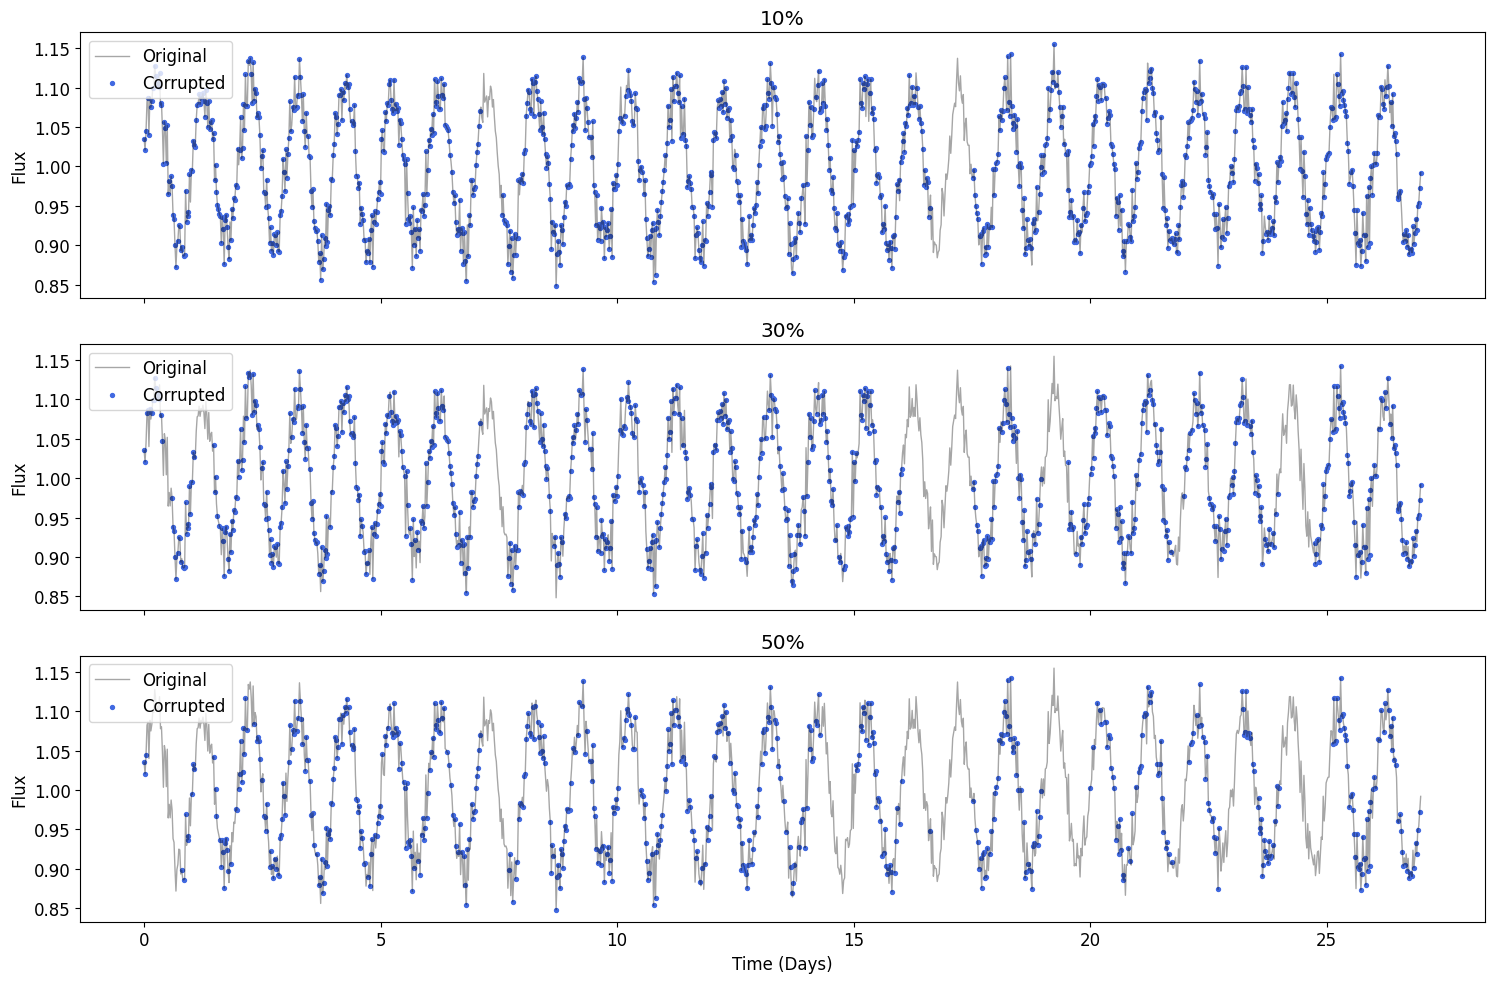

In [9]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(15,10),
    sharex=True
)

for ax, (name, df) in zip(axes, datasets.items()):

    ax.plot(
        df["time"],
        df["observed_flux"],
        color="black",
        linewidth=1,
        alpha=0.35,
        label="Original"
    )

    ax.scatter(
        df["time"],
        df["corrupted_flux"],
        s=8,
        color="royalblue",
        label="Corrupted"
    )

    ax.set_title(name)

    ax.set_ylabel("Flux")

    ax.legend()

plt.xlabel("Time (Days)")

plt.tight_layout()

plt.show()

- ## Missing Data Masks

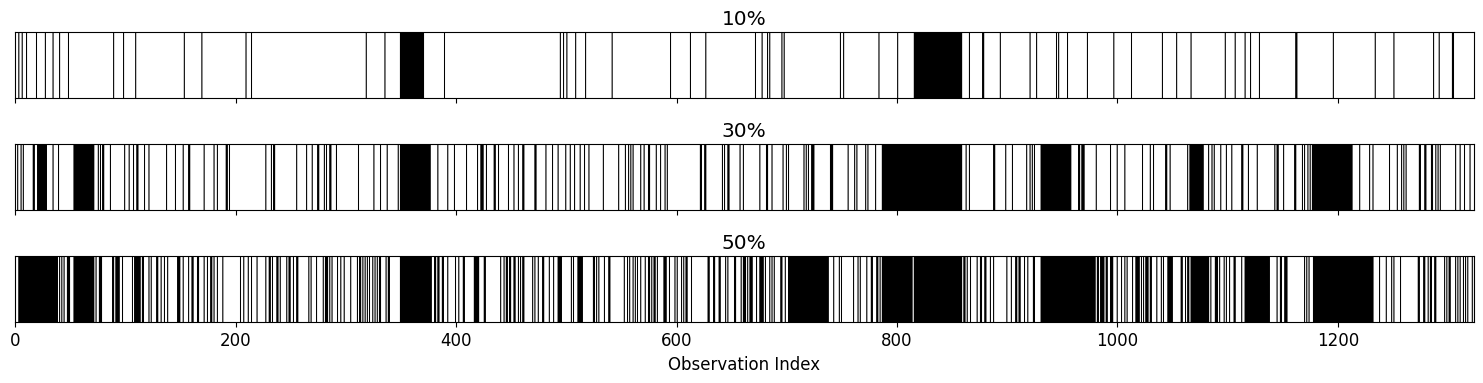

In [10]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(15,4),
    sharex=True
)

for ax, (name, df) in zip(axes, datasets.items()):

    ax.imshow(
        df["mask"].values.reshape(1,-1),
        cmap="gray",
        aspect="auto"
    )

    ax.set_title(name)

    ax.set_yticks([])

plt.xlabel("Observation Index")

plt.tight_layout()

plt.show()

- ## Function to Find Contiguous Gap Lengths

In [11]:
def get_gap_lengths(mask):
    """
    Compute the lengths of contiguous missing-value blocks.

    Parameters
    ----------
    mask : array-like
        Binary mask (1 = observed, 0 = missing)

    Returns
    -------
    list
        Length of every contiguous missing block.
    """

    gap_lengths = []

    current_length = 0

    for value in mask:

        if value == 0:

            current_length += 1

        else:

            if current_length > 0:

                gap_lengths.append(current_length)

                current_length = 0

    # Handle if series ends with a gap
    if current_length > 0:
        gap_lengths.append(current_length)

    return gap_lengths

- ## Compute Gap Statistics

In [12]:
gap_statistics = []

for name, df in datasets.items():

    lengths = get_gap_lengths(df["mask"].values)

    gap_statistics.append({

        "Dataset": name,

        "Number of Gaps": len(lengths),

        "Minimum": np.min(lengths),

        "Maximum": np.max(lengths),

        "Mean": np.mean(lengths),

        "Median": np.median(lengths),

        "Std": np.std(lengths)

    })

gap_statistics = pd.DataFrame(gap_statistics)

gap_statistics

,Dataset,Number of Gaps,Minimum,Maximum,Mean,Median,Std
0,10%,65,1,44,2.030769,1.0,5.849311
1,30%,164,1,73,2.420732,1.0,7.062426
2,50%,227,1,55,2.916300,1.0,7.162497


- ## Histogram of Gap Lengths

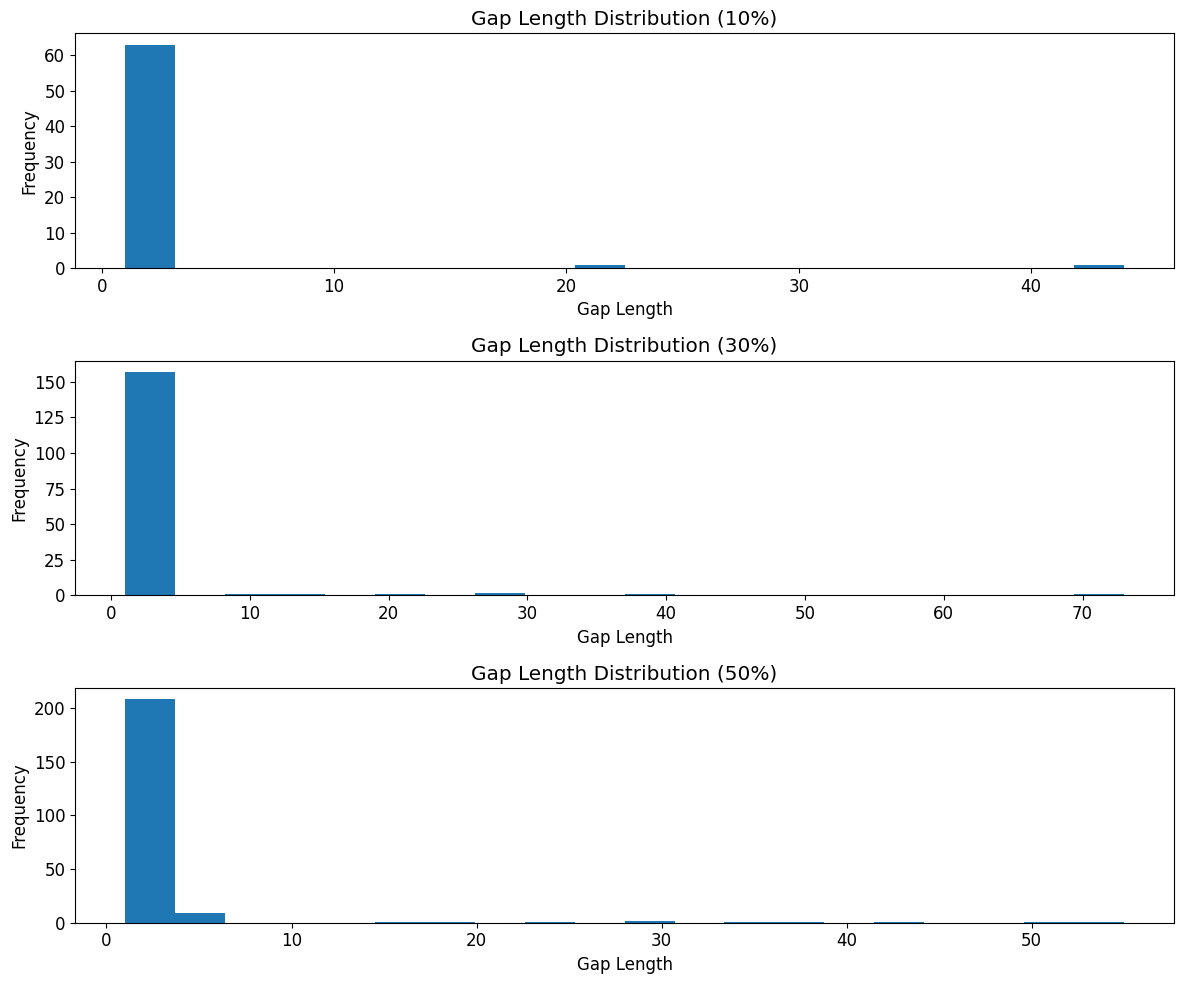

In [13]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(12,10)
)

for ax, (name, df) in zip(axes, datasets.items()):

    lengths = get_gap_lengths(df["mask"].values)

    ax.hist(
        lengths,
        bins=20
    )

    ax.set_title(f"Gap Length Distribution ({name})")

    ax.set_xlabel("Gap Length")

    ax.set_ylabel("Frequency")

plt.tight_layout()

plt.show()

- ## Boxplot of Gap Lengths

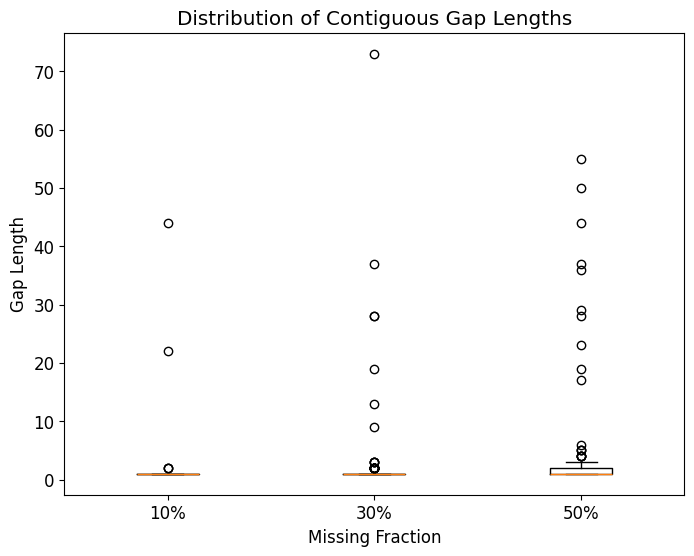

In [14]:
gap_data = []

labels = []

for name, df in datasets.items():

    gap_data.append(
        get_gap_lengths(df["mask"].values)
    )

    labels.append(name)

plt.figure(figsize=(8,6))

plt.boxplot(
    gap_data,
    tick_labels=labels
)

plt.xlabel("Missing Fraction")

plt.ylabel("Gap Length")

plt.title("Distribution of Contiguous Gap Lengths")

plt.show()

- ## Missing Value Locations

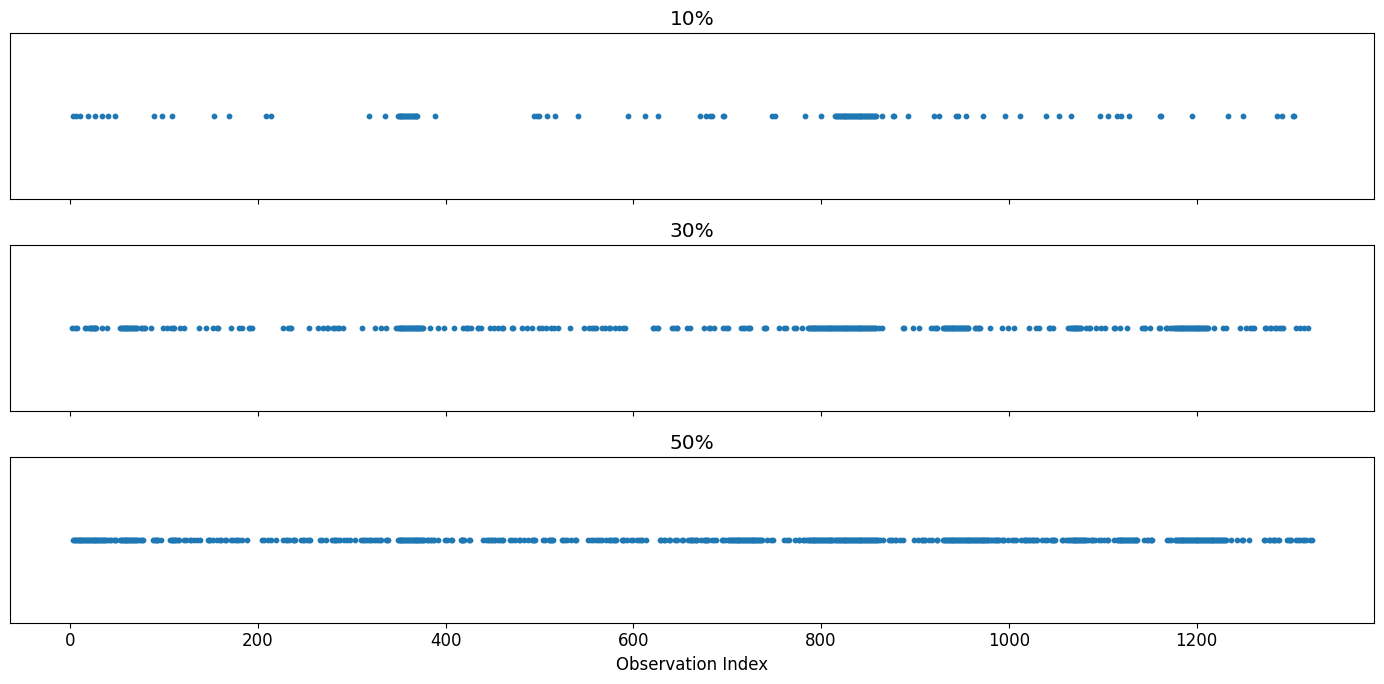

In [15]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(14,7),
    sharex=True
)

for ax, (name, df) in zip(axes, datasets.items()):

    missing = df[df["mask"] == 0]

    ax.scatter(

        missing.index,

        np.ones(len(missing)),

        s=10

    )

    ax.set_title(name)

    ax.set_yticks([])

plt.xlabel("Observation Index")

plt.tight_layout()

plt.show()

- ## Flux Distribution

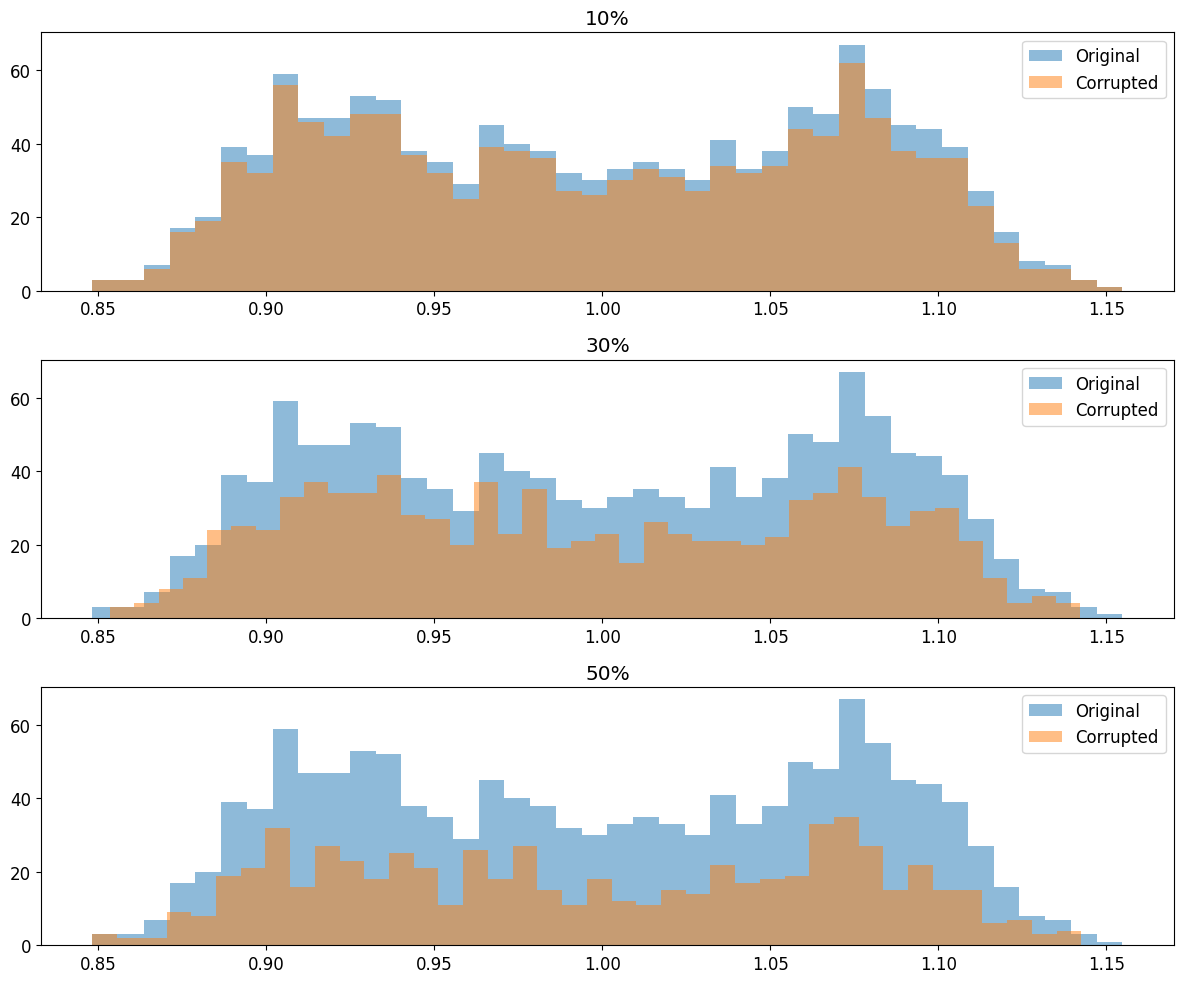

In [16]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(12,10)
)

for ax, (name, df) in zip(axes, datasets.items()):

    ax.hist(

        df["observed_flux"],

        bins=40,

        alpha=0.5,

        label="Original"

    )

    ax.hist(

        df["corrupted_flux"].dropna(),

        bins=40,

        alpha=0.5,

        label="Corrupted"

    )

    ax.set_title(name)

    ax.legend()

plt.tight_layout()

plt.show()

- ## Flux Summary Statistics

In [17]:
statistics = []

for name, df in datasets.items():

    statistics.append({

        "Dataset": name,

        "Mean Flux": df["corrupted_flux"].mean(),

        "Median Flux": df["corrupted_flux"].median(),

        "Std": df["corrupted_flux"].std(),

        "Minimum": df["corrupted_flux"].min(),

        "Maximum": df["corrupted_flux"].max()

    })

statistics = pd.DataFrame(statistics)

statistics

,Dataset,Mean Flux,Median Flux,Std,Minimum,Maximum
0,10%,0.997752,0.995811,0.073247,0.848224,1.154864
1,30%,0.996044,0.989980,0.072893,0.853494,1.142268
2,50%,0.996773,0.992973,0.073478,0.848224,1.142584


- ## Correlation Between Original and Corrupted Values

In [18]:
correlation = []

for name, df in datasets.items():

    valid = df["corrupted_flux"].notna()

    corr = np.corrcoef(
        df.loc[valid, "observed_flux"],
        df.loc[valid, "corrupted_flux"]
    )[0, 1]

    correlation.append({

        "Dataset": name,

        "Correlation": corr

    })

correlation = pd.DataFrame(correlation)

correlation

,Dataset,Correlation
0,10%,1.0
1,30%,1.0
2,50%,1.0
